In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


file_path = '../data/raw/dataset.csv'
df_raw = pd.read_csv(file_path, low_memory=False)

df = df_raw[['reviews.text', 'reviews.rating']].copy()
df.rename(columns={'reviews.text': 'text', 'reviews.rating': 'rating'}, inplace=True)


print("Eksik Değer Oranları (%):")
print((df.isnull().sum() / len(df)) * 100)


df.dropna(subset=['text', 'rating'], inplace=True)
df['rating'] = df['rating'].astype(int) 

df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

df = df[df['review_length'] >= 2]

df.head()

Eksik Değer Oranları (%):
text       0.000000
rating    26.299311
dtype: float64


,text,rating,review_length
0,I initially had trouble deciding between the p...,5,193
1,Allow me to preface this with a little history...,5,272
2,I am enjoying it so far. Great for reading. Ha...,4,35
3,I bought one of the first Paperwhites and have...,5,310
4,I have to say upfront - I don't like coroporat...,5,352


C:\Users\Zeki Kurt\AppData\Local\Temp\ipykernel_6804\3814021057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


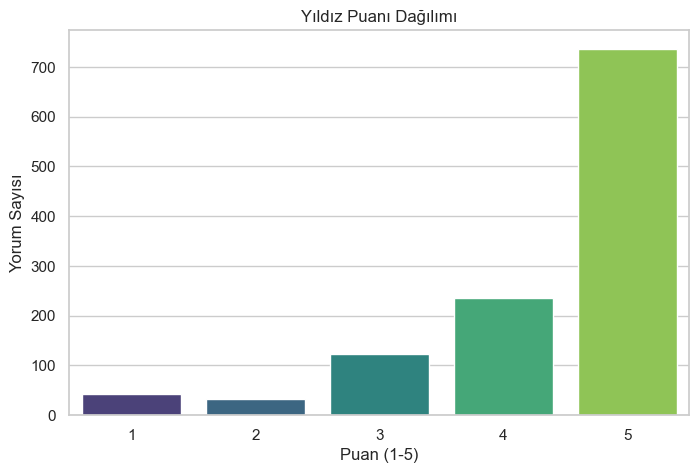

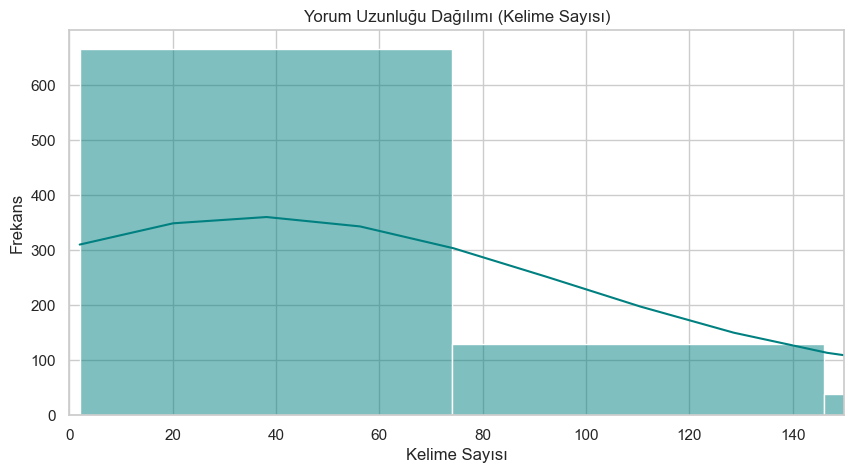

In [3]:
# 1. Yıldız Puanı Dağılımı
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Yıldız Puanı Dağılımı')
plt.xlabel('Puan (1-5)')
plt.ylabel('Yorum Sayısı')
plt.show()

# 2. Yorum Uzunluğu Dağılımı
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='review_length', bins=50, kde=True, color='teal')
plt.title('Yorum Uzunluğu Dağılımı (Kelime Sayısı)')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Frekans')
plt.xlim(0, 150) # Grafiği daha okunabilir kılmak için X eksenini limitleyelim
plt.show()

Orijinal Sınıf Dağılımı:
 sentiment
Positive    973
Neutral     124
Negative     75
Name: count, dtype: int64


C:\Users\Zeki Kurt\AppData\Local\Temp\ipykernel_6804\2104545019.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_balanced, x='sentiment', palette='Set2')


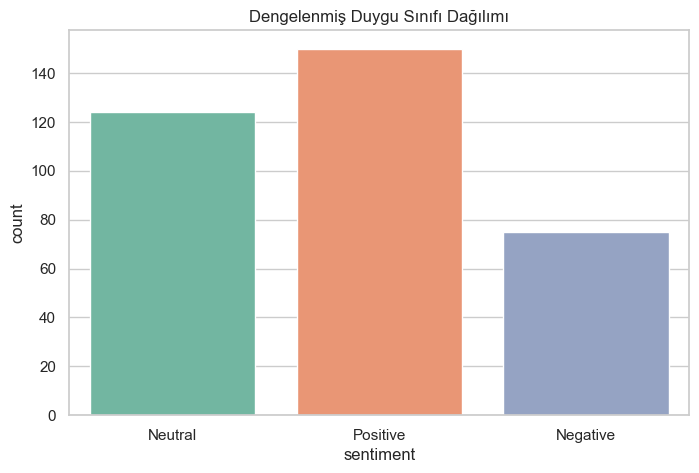

Veri temizlendi, dengelendi ve kaydedildi!


In [4]:
# 1'den 5'e kadar olan puanları duygu sınıflarına çevirme
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(map_sentiment)

print("Orijinal Sınıf Dağılımı:\n", df['sentiment'].value_counts())

# --- Sınıf Dengesizliği (Class Imbalance) Çözümü ---


min_class_size = df['sentiment'].value_counts().min()

df_negative = df[df['sentiment'] == 'Negative']
df_neutral = df[df['sentiment'] == 'Neutral']
df_positive = df[df['sentiment'] == 'Positive'].sample(n=min_class_size * 2, random_state=42) 


df_balanced = pd.concat([df_negative, df_neutral, df_positive])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True) 

plt.figure(figsize=(8, 5))
sns.countplot(data=df_balanced, x='sentiment', palette='Set2')
plt.title('Dengelenmiş Duygu Sınıfı Dağılımı')
plt.show()

df_balanced.to_csv('../data/processed/cleaned_reviews.csv', index=False)
print("Veri temizlendi, dengelendi ve kaydedildi!")